In [2]:
import numpy; print(numpy.__version__)   # want 1.26.x

1.26.4


In [3]:
### 1. SETUP

import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.preprocessing import ICA
from mne_bids import BIDSPath, read_raw_bids
from mne_icalabel import label_components
from autoreject import AutoReject, get_rejection_threshold

mne.set_log_level("WARNING")

BIDS_ROOT = "/Users/elizabethkaplan/Desktop/ds007615" #path to dataset
SUBJECT   = "07"
TASK      = "rest"
ACQ       = "ec"                 # 'ec' = eyes-closed, 'eo' = eyes-open

# Preproc parameters
L_FREQ, H_FREQ = 1.0, 40.0       # bandpass freqs
NOTCH_FREQS    = [50, 100]       # line noise + first harmonic (Norway = 50 Hz)
RESAMPLE_SFREQ = 256             # 2048 Hz is overkill for <40 Hz content
EOG_CHS        = ["HOG1", "HOG2", "VOG1", "VOG2"]
EPOCH_LEN      = 2.0             # ~4 min rest; used in amplitude thresholding step
N_JOBS         = 10             # AutoReject parallelism

### 2. LOAD DATA
bids_path = BIDSPath(subject=SUBJECT, task=TASK, acquisition=ACQ,
                     suffix="eeg", datatype="eeg", root=BIDS_ROOT)
raw = read_raw_bids(bids_path, verbose=False)
raw.load_data()
print(raw.info)
print("Duration: %.1f s | sfreq: %.0f Hz" % (raw.times[-1], raw.info["sfreq"]))

### 3. SET CHANNEL TYPES + MONTAGE
raw.set_channel_types({ch: "eog" for ch in EOG_CHS if ch in raw.ch_names})
if raw.get_montage() is None:
    raw.set_montage("standard_1005", on_missing="warn")

### 4. FILTER (notch + bandpass) + RESAMPLE
raw.notch_filter(freqs=NOTCH_FREQS, picks="eeg")
raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, picks=["eeg", "eog"], fir_design="firwin")
raw.resample(RESAMPLE_SFREQ)     # after filtering, to avoid aliasing

### 5. AMPLITUDE-THRESHOLD REJECTION
events = mne.make_fixed_length_events(raw, start=0, stop=raw.times[-1],
                                       duration=EPOCH_LEN)
epochs = mne.Epochs(raw, events=events, tmin=0.0, tmax=EPOCH_LEN,
                    baseline=None, picks="eeg", preload=True)

# Data-driven peak-to-peak threshold, then drop epochs exceeding it
reject = get_rejection_threshold(epochs, decim=1)
print("Rejection threshold:", reject)
epochs_clean = epochs.copy().drop_bad(reject=reject)
print("Kept %d/%d epochs after threshold" % (len(epochs_clean), len(epochs)))

### 6.ICA + ICLabel
epochs_clean.set_eeg_reference("average", projection=False)

ica = ICA(n_components=0.99, method="infomax", max_iter="auto",
          random_state=97, fit_params=dict(extended=True))
ica.fit(epochs_clean)

ic_labels = label_components(epochs_clean, ica, method="iclabel")
labels = ic_labels["labels"]
# Keep only "brain" and "other"; drop eye/muscle/heart/line/channel-noise
exclude_idx = [i for i, lab in enumerate(labels) if lab not in ("brain", "other")]
ica.exclude = exclude_idx
print("Component labels:", labels)
print("Excluding %d components: %s" % (len(exclude_idx), exclude_idx))

epochs_ica = ica.apply(epochs_clean.copy())

### 7. AUTOREJECT 
ar = AutoReject(n_jobs=N_JOBS, random_state=42, picks="eeg", verbose=False)
epochs_final, reject_log = ar.fit_transform(epochs_ica, return_log=True)
print("AutoReject removed %d/%d epochs" % (len(epochs_ica) - len(epochs_final),
                                           len(epochs_ica)))
print("Final epochs:", len(epochs_final))

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 64 EEG, 4 EOG
 custom_ref_applied: False
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 1024.0 Hz
 meas_date: unspecified
 nchan: 68
 projs: []
 sfreq: 2048.0 Hz
 subject_info: 5 items (dict)
>
Duration: 245.5 s | sfreq: 2048 Hz
Estimating rejection dictionary for eeg
Rejection threshold: {'eeg': 0.0004965006339997988}
Kept 122/122 epochs after threshold


/var/folders/s6/21s_2dfj2f195fl1lglp7jrw0000gn/T/ipykernel_26205/880709067.py:64: RuntimeWarning: The provided Epochs instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(epochs_clean, ica, method="iclabel")


Component labels: ['brain', 'eye blink', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'eye blink', 'brain', 'brain', 'brain', 'brain', 'channel noise', 'brain', 'eye blink', 'other', 'brain', 'brain', 'other', 'brain', 'other', 'channel noise', 'other', 'brain', 'brain', 'brain', 'other', 'other', 'muscle artifact', 'other', 'muscle artifact', 'other']
Excluding 7 components: [1, 9, 14, 16, 23, 30, 32]
AutoReject removed 7/122 epochs
Final epochs: 115


/var/folders/s6/21s_2dfj2f195fl1lglp7jrw0000gn/T/ipykernel_26205/3816120043.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


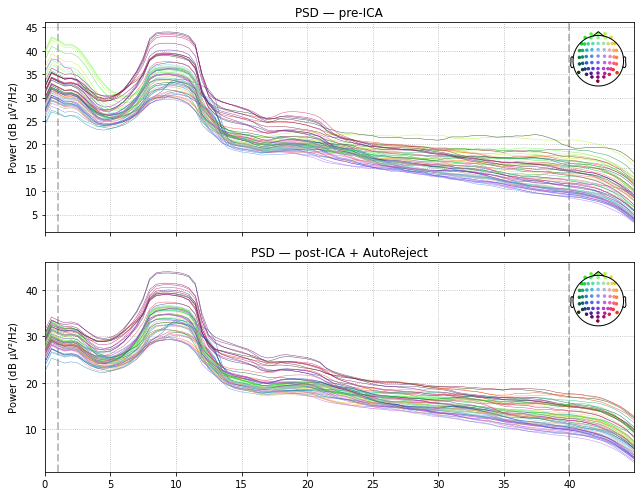

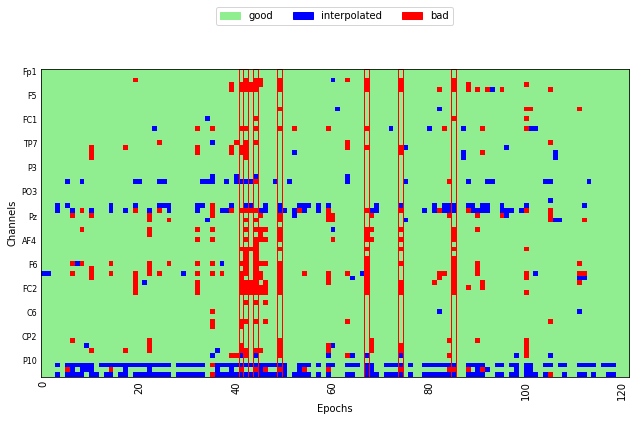

Saved: sub-07_task-rest_acq-ec_clean-epo.fif


In [4]:
# QUALITY CHECK

# PSD before vs after component removal
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
epochs_clean.compute_psd(fmax=45).plot(axes=axes[0], show=False)
axes[0].set_title("PSD — pre-ICA")
epochs_final.compute_psd(fmax=45).plot(axes=axes[1], show=False)
axes[1].set_title("PSD — post-ICA + AutoReject")
plt.tight_layout()

# AutoReject drop/interpolate log
reject_log.plot("horizontal")

plt.show()

# SAVE
out = f"sub-{SUBJECT}_task-{TASK}_acq-{ACQ}_clean-epo.fif"
epochs_final.save(out, overwrite=True)
print("Saved:", out)